## Show, Attend and Tell — Training (Flickr8k)


In [1]:
# Reinstall ipython kernel to enable autoreload on latest runtime (by 02/12/2026)
# You'll be prompted to restart the session.
!pip install ipython==8.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.4/796.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.3 MB/s eta 0:00:00
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 8.12.0 which is incompatible.


In [ ]:
%load_ext autoreload
%autoreload 2

Clone repository

In [ ]:
!git clone https://github.com/seanzhangw/show-attend-tell.git

Pull recent changes

In [ ]:
%cd /content/show-attend-tell
!git pull

Get dataset

In [ ]:
from google.colab import drive
import sys

drive.mount('/content/gdrive')

# NOTE: Change this path to your own Google Drive path
base_dir = "/content/gdrive/MyDrive/CS5782/show-attend-tell"
sys.path.append(base_dir)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
%cd /content/gdrive/MyDrive/CS5782/show-attend-tell/data
!python get_flickr8k.py

/content/gdrive/MyDrive/CS5782/show-attend-tell/data
Using Colab cache for faster access to the 'flickr8k' dataset.
Downloaded to: /kaggle/input/flickr8k
Dataset available at: /content/gdrive/MyDrive/CS5782/show-attend-tell/data/flickr8k


Imports

In [ ]:
# %cd /content/show-attend-tell/code
%cd /content/gdrive/MyDrive/CS5782/show-attend-tell/code

import os

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import multiprocessing

import config
from datasets.flickr8k import collate_fn, build_flickr8k_dataset_split
from eval.greedy_decode import greedy_decode
from models.encoder import EncoderCNN
from models.decoder import Decoder


/content/gdrive/MyDrive/CS5782/show-attend-tell/code


Define Hyperparameters

In [ ]:
# Hyperparameters (edit as needed)
epochs = 8
batch_size = config.BATCH_SIZE
lr = 1e-4
embed_dim = 512
hidden_dim = 512
attention_dim = 512

dropout = 0.5
lambda_att = 1.0
grad_clip = 5.0
val_ratio = 0.1
split_seed = 42
# BLEU-4: cap images per eval for speed (None = all val images)
bleu_max_images = 500

Build datasets, dataloaders

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            # ImageNet normalization for pre-trained ResNet (ImageNet dataset mean and std)
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)

# Dataset: image-level train/val split; vocab from train captions only
(
    train_set,
    val_set,
    val_image_ids,
    full_captions_map,
    word2idx,
    idx2word,
) = build_flickr8k_dataset_split(
    config,
    transform=transform,
    val_ratio=val_ratio,
    seed=split_seed,
)
pad_idx = word2idx["<pad>"]
print(
    f"Train samples: {len(train_set)} | Val samples: {len(val_set)} | "
    f"Val images: {len(val_image_ids)} | Vocab size: {len(word2idx)}"
)

cores = multiprocessing.cpu_count()

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=cores,
    pin_memory=True,
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=cores,
    pin_memory=True,
)

Using device: cuda
Train samples: 36410 | Val samples: 4045 | Val images: 809 | Vocab size: 8363


Initialize models, loss, and optimizer

In [ ]:
# Models
encoder = EncoderCNN().to(device)
decoder = Decoder(
    vocab_size=len(word2idx),
    embed_dim=embed_dim,
    feature_dim=2048,
    hidden_dim=hidden_dim,
    attention_dim=attention_dim,
    dropout=dropout,
).to(device)

# Loss / Optimizer
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

# Only decoder trained since encoder uses resnet50
params = list(decoder.parameters())

optimizer = torch.optim.Adam(params, lr=lr)

In [ ]:
# Copy image from Drive to Local
import os
import shutil
import config

drive_path = "/content/gdrive/MyDrive/CS5782/show-attend-tell/data/flickr8k/Images"
local_path = "/content/Images"

if not os.path.exists(local_path):
    print("Copying images from Drive to local SSD...")
    shutil.copytree(drive_path, local_path)
    print("Copy complete!")

# Point the code to the fast local drive
config.IMAGE_DIR = local_path

Copying images from Drive to local SSD...
Copy complete!


In [ ]:
# Meteor
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Training loop. Current config starts training from scratch

In [ ]:
from training.loop import evaluate_caption_metrics, run_training_loop
from training.run_spec import CorpusEvalSpec, TrainLoopOptions

CHECKPOINT_DIR = "./checkpoints"
RESUME_PATH = "./checkpoints/best_by_val_loss.pt"  # e.g. "./checkpoints/best_by_val_loss.pt"
EVAL_METRICS = ["bleu1", "bleu2", "bleu3", "bleu4", "meteor"]  # add "meteor" after nltk.download(...)
BEST_BY = "val_loss"  # best checkpoint by this key; min for train_loss/val_loss, max for BLEU etc.

corpus_eval = CorpusEvalSpec(
    val_image_ids=val_image_ids,
    full_captions_map=full_captions_map,
    image_dir=config.IMAGE_DIR,
    transform=transform,
    word2idx=word2idx,
    idx2word=idx2word,
    eval_metric_names=EVAL_METRICS,
    max_decode_len=config.MAX_LEN,
    max_images=bleu_max_images,
)

train_options = TrainLoopOptions(
    checkpoint_dir=CHECKPOINT_DIR,
    best_by=BEST_BY,
    resume_path=RESUME_PATH,
    lambda_att=lambda_att,
    grad_clip=grad_clip,
    print_every=100,
)

_, best_ckpt_path, _ = run_training_loop(
    encoder,
    decoder,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    corpus_eval,
    train_options,
    hparams={
        "embed_dim": embed_dim,
        "hidden_dim": hidden_dim,
        "attention_dim": attention_dim,
        "dropout": dropout,
        "lambda_att": lambda_att,
        "lr": lr,
        "batch_size": batch_size,
        "val_ratio": val_ratio,
        "split_seed": split_seed,
    },
)


[fit] start_epoch 9 > epochs 8; nothing to run.


Optional model evaluation (also runs in training loop)

In [ ]:
# Eval-only metrics (no training step)
metric_scores = evaluate_caption_metrics(encoder, decoder, device, corpus_eval)
print("Eval-only metrics:", metric_scores)

Eval-only metrics: {'bleu1': 0.5996929572059105, 'bleu2': 0.4136257393812129, 'bleu3': 0.27785695031548985, 'bleu4': 0.1881950271155735, 'meteor': 0.3954063209109097}


Eye Test - generate captions on validation images

In [ ]:
from PIL import Image

num_examples = min(20, len(val_image_ids))
print(f"\nQualitative eval on {num_examples} validation images (unique)")

for i, img_name in enumerate(sorted(val_image_ids)[:num_examples]):
    path = os.path.join(config.IMAGE_DIR, img_name)
    image = Image.open(path).convert("RGB")
    image_tensor = transform(image)

    pred_tokens = greedy_decode(
        encoder,
        decoder,
        image_tensor,
        word2idx,
        idx2word,
        device,
        max_len=config.MAX_LEN,
    )
    refs = full_captions_map[img_name][:5]

    print(f"\n[{i+1:02d}] Image: {img_name}")
    print("Generated:", " ".join(pred_tokens) if pred_tokens else "<empty>")
    for j, ref in enumerate(refs[:3], start=1):
        print(f"Ref {j}: {ref}")



Qualitative eval on 20 validation images (unique)

[01] Image: 101654506_8eb26cfb60.jpg
Generated: a dog runs through the snow
Ref 1: a brown and white dog is running through the snow .
Ref 2: a dog is running in the snow
Ref 3: a dog running through snow .

[02] Image: 104136873_5b5d41be75.jpg
Generated: a person sitting on a mountain covered in front of a mountain
Ref 1: people sit on the mountainside and check out the view .
Ref 2: three people are on a hilltop overlooking a green valley .
Ref 3: three people hang out on top of a big hill .

[03] Image: 1042020065_fb3d3ba5ba.jpg
Generated: a man is being full by a man in a yellow canoe
Ref 1: a boy in a green shirt is looking down at many inflatable boats .
Ref 2: a boy in a green shirt watches kayakers .
Ref 3: a boy looks over a railing at the many boats and rafts below in the water .

[04] Image: 1048710776_bb5b0a5c7c.jpg
Generated: a group of people sit on a beach
Ref 1: a couple of several people sitting on a ledge overlooking

Save the trained model to Google Drive

Connects to google drive

Saves the model file to drive

In [ ]:
import shutil
import os

# Define the source (where the model is now) and destination (your Drive)
source_path = './checkpoints/best_by_val_loss.pt'
dest_path = os.path.join(base_dir, 'best_by_val_loss_4_19.pt')

# Create the directory on Drive if it doesn't exist
os.makedirs(base_dir, exist_ok=True)

# Copy the file
shutil.copyfile(source_path, dest_path)

print(f"Model successfully saved to: {dest_path}")

Model successfully saved to: /content/gdrive/MyDrive/CS5782/show-attend-tell/best_by_val_loss_4_19.pt


Loading a model into encoder_loaded, decoder_loaded variables. If running the training loop, need to change variable names

In [ ]:
# Load encoder/decoder from a checkpoint stored on Google Drive
from training.checkpoint import load_models_from_checkpoint_path

# Path on Drive where we saved the checkpoint above
ckpt_path = os.path.join(base_dir, "best_by_val_loss_4_19.pt")
print("Loading checkpoint from:", ckpt_path)

# Re-create model objects with the same architecture as during training
encoder_loaded = EncoderCNN().to(device)
decoder_loaded = Decoder(
    vocab_size=len(word2idx),
    embed_dim=embed_dim,
    feature_dim=2048,
    hidden_dim=hidden_dim,
    attention_dim=attention_dim,
    dropout=dropout,
).to(device)

# (Optional) create an optimizer if you want to resume training
optimizer_loaded = torch.optim.Adam(list(decoder_loaded.parameters()), lr=lr)

resume_info = load_models_from_checkpoint_path(
    ckpt_path,
    encoder_loaded,
    decoder_loaded,
    optimizer=optimizer_loaded,  # set to None if you only care about inference
    map_location=device,
)

print("Start epoch after restore:", resume_info["start_epoch"])
print("Last metrics in checkpoint:", resume_info["metrics"])
print("Tracking info:", resume_info["tracking"])

Loading checkpoint from: /content/gdrive/MyDrive/CS5782/show-attend-tell/best_by_val_loss_4_19.pt
Start epoch after restore: 9
Last metrics in checkpoint: {'train_loss': 2.831515290196625, 'val_loss': 3.4500513283286507, 'bleu1': 0.6234887737478411, 'bleu2': 0.43957622480388, 'bleu3': 0.30094689330196406, 'bleu4': 0.2044743795224852}
Tracking info: {'best_value': 3.4500513283286507, 'best_epoch': 8, 'best_metric_key': 'val_loss', 'best_mode': 'min'}


Visualizing Attention For: 1674612291_7154c5ab61.jpg


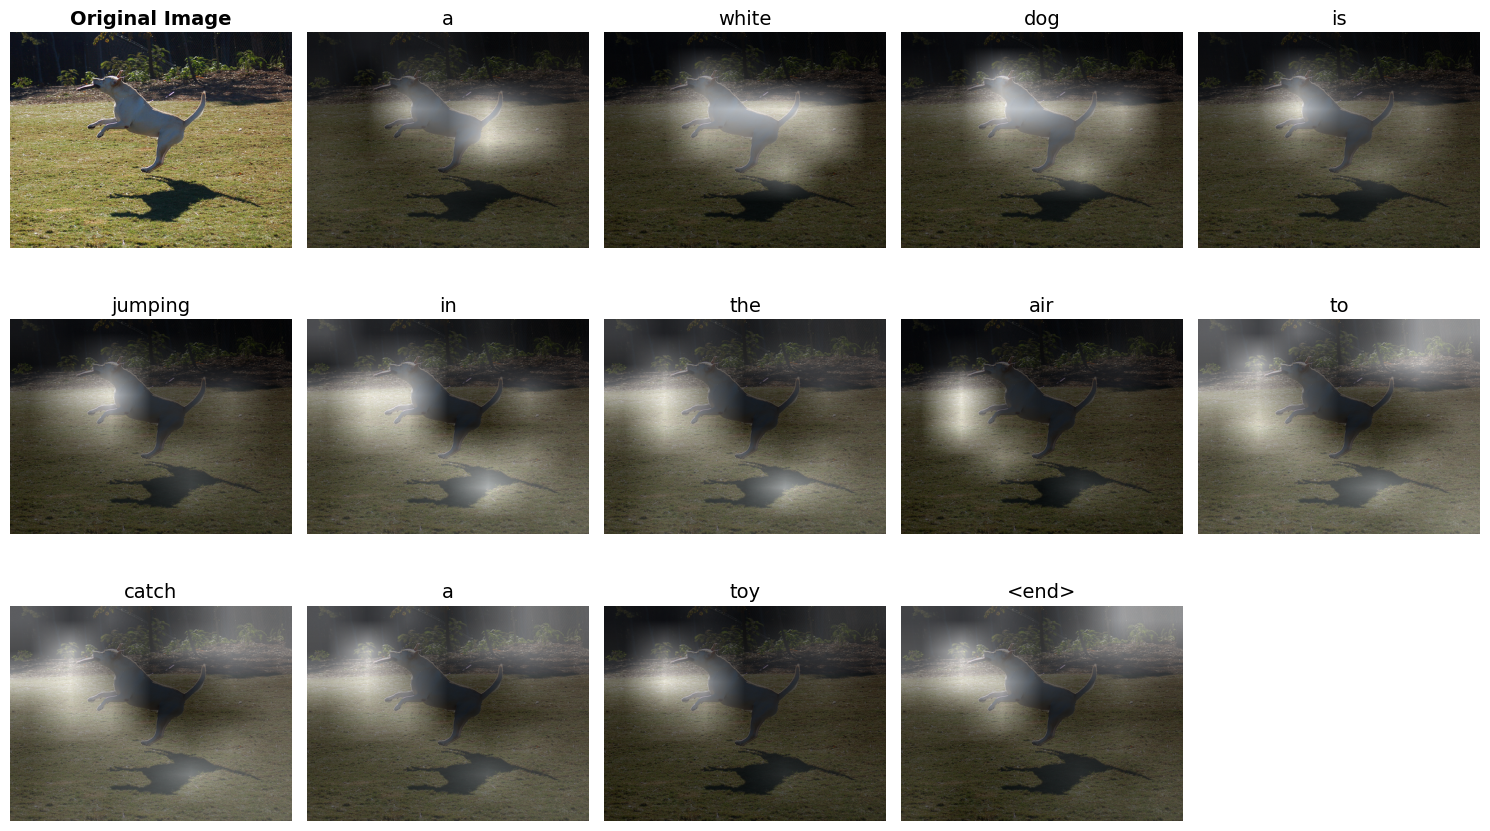

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import os
import random

@torch.no_grad()
def plot_attention_map(encoder, decoder, image_path, word2idx, idx2word, transform, device, max_len=20):
    encoder.eval()
    decoder.eval()

    # 1. Load and transform the image
    original_img = Image.open(image_path).convert("RGB")
    img_tensor = transform(original_img).unsqueeze(0).to(device)

    # 2. Extract features
    features = encoder(img_tensor)

    # 3. Generate caption AND capture the attention weights
    start_id = word2idx["<start>"]
    sampled_ids, alphas = decoder.sample(features, start_token_id=start_id, max_len=max_len)

    sampled_ids = sampled_ids[0].tolist()
    alphas = alphas[0].cpu().numpy()

    # 4. Decode the words
    words = []
    valid_alphas = []

    for i, token_id in enumerate(sampled_ids):
        w = idx2word.get(token_id, "<unk>")
        if w == "<start>":
            continue

        words.append(w)
        valid_alphas.append(alphas[i])

        if w == "<end>":
            break

    # 5. Plotting the results
    num_words = len(words)
    cols = 5
    # Add +1 to the total count to make room for the original image
    rows = (num_words + 1 + cols - 1) // cols

    fig = plt.figure(figsize=(15, 3 * rows))

    # --- PLOT 1: The Original Image ---
    ax = fig.add_subplot(rows, cols, 1)
    ax.imshow(original_img)
    ax.set_title("Original Image", fontsize=14, fontweight="bold")
    ax.axis('off')

    # --- PLOT 2+: The Attention Maps ---
    for i in range(num_words):
        ax = fig.add_subplot(rows, cols, i + 2) # i + 2 offsets by 1 for the original image
        w = words[i]

        grid_size = int(np.sqrt(valid_alphas[i].shape[0]))
        att_map = valid_alphas[i].reshape(grid_size, grid_size)

        att_map = Image.fromarray(att_map)
        att_map = att_map.resize(original_img.size, resample=Image.BILINEAR)

        ax.imshow(original_img)
        ax.imshow(np.array(att_map), cmap='gray', alpha=0.7)

        ax.set_title(w, fontsize=14)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


# --- How to run it ---
# Grab all the image filenames in your dataset folder
all_images = os.listdir(config.IMAGE_DIR)

# Pick a random one! Every time you run this cell, you get a new image.
random_image_name = random.choice(all_images)
test_image_path = os.path.join(config.IMAGE_DIR, random_image_name)

print(f"Visualizing Attention For: {random_image_name}")

plot_attention_map(
    encoder,
    decoder,
    test_image_path,
    word2idx,
    idx2word,
    transform,
    device
)

## Hard Attention (REINFORCE)

Hard attention samples **one spatial location** per timestep from the attention distribution rather than taking a weighted average of all locations. Because sampling is non-differentiable, the attention weights are trained with **REINFORCE**: the reward signal is the caption log-likelihood, and a moving-average baseline reduces variance.

The decoder architecture is identical to the soft-attention `Decoder`; only the attention module and training loop differ.

In [ ]:
from models.decoder import HardDecoder
from training.loop import run_training_loop_hard
from training.run_spec import TrainLoopOptions

# Hard-attention specific hyperparameters
# lambda_reinforce: weight on the REINFORCE gradient term
# lambda_entropy:   entropy bonus on the attention distribution (>0 encourages
#                   exploration early in training; 0.01 is a safe default)
# baseline_decay:   EMA decay for the variance-reduction baseline (0.9 recommended)
lambda_reinforce = 1.0
lambda_entropy   = 0.01
baseline_decay   = 0.9

HARD_CHECKPOINT_DIR = "./checkpoints_hard"
HARD_RESUME_PATH    = None   # set to e.g. "./checkpoints_hard/best_by_val_loss.pt" to resume

In [ ]:
# Build hard-attention decoder — same architecture as soft Decoder
hard_decoder = HardDecoder(
    vocab_size=len(word2idx),
    embed_dim=embed_dim,
    feature_dim=2048,
    hidden_dim=hidden_dim,
    attention_dim=attention_dim,
    dropout=dropout,
).to(device)

# encoder is shared and stays frozen (eval mode in both training loops)
hard_optimizer = torch.optim.Adam(hard_decoder.parameters(), lr=lr)

print(f"HardDecoder parameters: {sum(p.numel() for p in hard_decoder.parameters()):,}")

In [ ]:
hard_corpus_eval = CorpusEvalSpec(
    val_image_ids=val_image_ids,
    full_captions_map=full_captions_map,
    image_dir=config.IMAGE_DIR,
    transform=transform,
    word2idx=word2idx,
    idx2word=idx2word,
    eval_metric_names=EVAL_METRICS,
    max_decode_len=config.MAX_LEN,
    max_images=bleu_max_images,
)

hard_options = TrainLoopOptions(
    checkpoint_dir=HARD_CHECKPOINT_DIR,
    best_by=BEST_BY,
    resume_path=HARD_RESUME_PATH,
    grad_clip=grad_clip,
    lambda_reinforce=lambda_reinforce,
    lambda_entropy=lambda_entropy,
    baseline_decay=baseline_decay,
    print_every=100,
)

_, hard_ckpt_path, _ = run_training_loop_hard(
    encoder,
    hard_decoder,
    train_loader,
    val_loader,
    criterion,
    hard_optimizer,
    device,
    epochs,
    hard_corpus_eval,
    pad_idx=pad_idx,
    options=hard_options,
    hparams={
        "embed_dim": embed_dim,
        "hidden_dim": hidden_dim,
        "attention_dim": attention_dim,
        "dropout": dropout,
        "lambda_reinforce": lambda_reinforce,
        "lambda_entropy": lambda_entropy,
        "baseline_decay": baseline_decay,
        "lr": lr,
        "batch_size": batch_size,
        "val_ratio": val_ratio,
        "split_seed": split_seed,
    },
)

### Evaluation

In [ ]:
from training.loop import evaluate_caption_metrics

hard_scores = evaluate_caption_metrics(encoder, hard_decoder, device, hard_corpus_eval)
soft_scores = evaluate_caption_metrics(encoder, decoder,      device, corpus_eval)

print(f"{'Metric':<10} {'Soft':>10} {'Hard':>10}")
print("-" * 32)
for k in hard_scores:
    print(f"{k:<10} {soft_scores[k]:>10.4f} {hard_scores[k]:>10.4f}")

In [ ]:
# Eye test — side-by-side captions from both models on the same validation images
num_examples = min(10, len(val_image_ids))
print(f"Qualitative comparison on {num_examples} validation images\n")

for i, img_name in enumerate(sorted(val_image_ids)[:num_examples]):
    path = os.path.join(config.IMAGE_DIR, img_name)
    image_tensor = transform(Image.open(path).convert("RGB"))

    soft_tokens = greedy_decode(encoder, decoder,      image_tensor, word2idx, idx2word, device, max_len=config.MAX_LEN)
    hard_tokens = greedy_decode(encoder, hard_decoder, image_tensor, word2idx, idx2word, device, max_len=config.MAX_LEN)
    refs = full_captions_map[img_name][:3]

    print(f"[{i+1:02d}] {img_name}")
    print(f"  Soft : {' '.join(soft_tokens) or '<empty>'}")
    print(f"  Hard : {' '.join(hard_tokens) or '<empty>'}")
    for j, ref in enumerate(refs, 1):
        print(f"  Ref {j}: {ref}")
    print()

### Attention visualisation (Hard)

Hard attention selects **one grid cell** per word, so the overlay shows a single highlighted patch rather than a smooth heatmap.

In [ ]:
random_image_name = random.choice(all_images)
test_image_path   = os.path.join(config.IMAGE_DIR, random_image_name)
print(f"Visualizing Hard Attention for: {random_image_name}")

# plot_attention_map works unchanged because hard_decoder.sample()
# returns (sampled_ids, alphas) with the same shape as the soft decoder.
# alphas here is the full soft distribution alpha (not a one-hot), so the
# visualisation shows where the model *concentrated* its distribution even
# though it only sampled one location during training.
plot_attention_map(
    encoder,
    hard_decoder,
    test_image_path,
    word2idx,
    idx2word,
    transform,
    device,
)

### Save / Load hard-attention checkpoint

In [ ]:
import shutil

hard_source = hard_ckpt_path
hard_dest   = os.path.join(base_dir, "hard_best_by_val_loss.pt")

shutil.copyfile(hard_source, hard_dest)
print(f"Hard-attention checkpoint saved to: {hard_dest}")

In [ ]:
from training.checkpoint import load_models_from_checkpoint_path

hard_ckpt_drive = os.path.join(base_dir, "hard_best_by_val_loss.pt")
print("Loading hard-attention checkpoint from:", hard_ckpt_drive)

encoder_hard_loaded = EncoderCNN().to(device)
decoder_hard_loaded = HardDecoder(
    vocab_size=len(word2idx),
    embed_dim=embed_dim,
    feature_dim=2048,
    hidden_dim=hidden_dim,
    attention_dim=attention_dim,
    dropout=dropout,
).to(device)

resume_info = load_models_from_checkpoint_path(
    hard_ckpt_drive,
    encoder_hard_loaded,
    decoder_hard_loaded,
    map_location=device,
)
print("Start epoch after restore:", resume_info["start_epoch"])
print("Last metrics in checkpoint:", resume_info["metrics"])
print("Tracking info:", resume_info["tracking"])